# Phase 6 — Machine Learning

## NYC Real Estate Price Prediction

### Objective

This notebook develops an end-to-end machine-learning pipeline to predict NYC property **`listing_price`** using property characteristics, geographic information, listing details, and available market-value estimates.

### Models
1. **Linear Regression** — baseline model
2. **Random Forest** — nonlinear ensemble model
3. **XGBoost** — gradient-boosting model

### Evaluation Metrics
- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error
- **R²** — coefficient of determination

The models are evaluated on the same held-out test set. The final model is selected based on measured performance rather than assuming that the most complex model will perform best.

> **Important:** Features derived directly or indirectly from `listing_price` are excluded to prevent target leakage.

## 1. Import Libraries

The notebook uses Pandas and NumPy for data handling, Matplotlib for visualization, Scikit-learn for preprocessing and evaluation, XGBoost for gradient boosting, and Joblib for model persistence.

Preprocessing is kept inside Scikit-learn pipelines so that transformations are learned from training data and applied consistently to unseen data.

In [5]:
# If XGBoost is not installed, install it once in your environment:
 # %pip install -q xgboost

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import xgboost as xgb

RANDOM_STATE = 42
TEST_SIZE = 0.20

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import xgboost as xgb

import joblib

## 2. Load the Feature-Engineered Dataset

The modeling stage uses the feature-engineered dataset created in the previous phase.

For a GitHub repository, the recommended structure is:

```text
project/
├── data/
│   └── processed/
│       └── feature_engineered_zillow_dataset.csv
└── notebooks/
    └── 05_model_training.ipynb
```

The fallback path supports the Google Colab location used during development.

In [7]:
# Load the dataset using the repository path first, with a Colab fallback.
DATA_PATH = Path("../data/processed/feature_engineered_zillow_dataset.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("/content/feature_engineered_zillow_dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Expected "
        "'../data/processed/feature_engineered_zillow_dataset.csv' "
        "or '/content/feature_engineered_zillow_dataset.csv'."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")

Dataset loaded from: /content/feature_engineered_zillow_dataset.csv
Dataset shape: (1892, 39)


In [8]:
# Preview the first five records.
df.head()

,address,zip_code,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,...,rental_yield_score,price_sqft_score,tax_assessment_ratio,tax_value_score,zip_median_price_x,zip_median_price_y,zip_median_price,location_score,investment_score,investment_rating
0,"572 Louisiana Avenue #1, Brooklyn, NY 11239",11239,2.0,2.0,1017.0,40.647620,-73.886810,250000.0,3550.0,856400.0,...,95.983087,93.763214,2.281176,85.517970,452000.0,452000.0,452000.0,11.284355,72.7,Good
1,"2183 Ocean Ave #4A, Brooklyn, NY 11229",11229,1.0,1.0,541.0,40.608430,-73.952736,485000.0,2489.0,473800.0,...,63.583510,9.566596,1.684536,80.443975,350000.0,350000.0,350000.0,4.889006,37.9,Below Average
2,"8885 15th Ave, Brooklyn, NY 11228",11228,4.0,3.0,2060.0,40.605550,-74.015200,1299000.0,5015.0,1315600.0,...,38.900634,29.651163,1.016166,62.156448,1280000.0,1280000.0,1280000.0,91.014799,53.1,Moderate
3,"300 Milford St, Brooklyn, NY 11208",11208,3.0,2.0,1232.0,40.671783,-73.876625,595000.0,3574.0,602800.0,...,73.572939,57.505285,1.225210,74.392178,809500.0,809500.0,809500.0,37.764271,60.7,Moderate
4,"2711 Avenue X Unit F2, Brooklyn, NY 11235",11235,2.0,1.0,1000.0,40.704254,-73.966420,345000.0,3056.0,350500.0,...,85.465116,84.645877,2.368116,86.310782,527000.0,527000.0,527000.0,13.662791,67.4,Good


In [9]:
# Confirm the number of observations and columns.
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 1,892
Columns: 39


In [10]:
# Review data types and non-null counts before modeling.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1892 entries, 0 to 1891
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   address                 1892 non-null   object 
 1   zip_code                1892 non-null   int64  
 2   bedrooms                1892 non-null   float64
 3   bathrooms               1892 non-null   float64
 4   living_area             1892 non-null   float64
 5   latitude                1892 non-null   float64
 6   longitude               1892 non-null   float64
 7   listing_price           1892 non-null   float64
 8   rent_estimate           1892 non-null   float64
 9   zestimate               1892 non-null   float64
 10  home_type               1892 non-null   object 
 11  days_on_zillow          1892 non-null   int64  
 12  listing_status          1892 non-null   object 
 13  zpid                    1892 non-null   int64  
 14  tax_assessed_value      1892 non-null   

## 3. Validate the Target Variable

The prediction target is **`listing_price`**.

Before training, we verify that the target:
- exists,
- contains no missing values,
- contains no zero or negative prices.

Invalid target values should be resolved during data cleaning rather than imputed during model preprocessing.

In [11]:
TARGET = "listing_price"

if TARGET not in df.columns:
    raise KeyError(f"Target column '{TARGET}' was not found.")

missing_target = df[TARGET].isna().sum()
non_positive_target = (df[TARGET] <= 0).sum()

print(f"Missing target values: {missing_target}")
print(f"Non-positive target values: {non_positive_target}")

if missing_target > 0 or non_positive_target > 0:
    raise ValueError(
        "The target contains missing or non-positive values. "
        "Clean these records before model training."
    )

Missing target values: 0
Non-positive target values: 0


In [12]:
# The previous validation cell already counts non-positive prices.
# This assertion keeps the target validation explicit.
assert (df[TARGET] > 0).all(), "Found non-positive listing prices."

In [13]:
# Inspect the distribution of listing prices.
df[TARGET].describe()

,listing_price
count,1.892000e+03
mean,1.023330e+06
std,1.248418e+06
min,3.600000e+03
25%,5.500000e+05
50%,8.500000e+05
75%,1.191250e+06
max,2.500000e+07


## 4. Define the Modeling Features

The model uses features representing property characteristics, location, listing context, and market-value estimates.

**Property:** `bedrooms`, `bathrooms`, `living_area`

**Location:** `latitude`, `longitude`, `zip_code`

**Listing:** `home_type`, `listing_status`, `days_on_zillow`

**Market/value estimates:** `rent_estimate`, `tax_assessed_value`, `zestimate`

**Missingness indicators:** existing indicators created during feature engineering are retained.

> **Important:** Missingness indicators should be created from the original missingness state. Creating them after values have already been imputed would incorrectly make every indicator zero.

In [14]:
base_features = [
    "bedrooms",
    "bathrooms",
    "living_area",
    "latitude",
    "longitude",
    "zip_code",
    "home_type",
    "listing_status",
    "days_on_zillow",
    "rent_estimate",
    "tax_assessed_value",
    "zestimate",
]

# Prefer missingness indicators created during feature engineering.
indicator_candidates = {
    "rent_estimate_missing": ["rent_missing", "rent_estimate_missing"],
    "tax_assessed_value_missing": [
        "tax_assessed_missing",
        "tax_assessed_value_missing",
        "tax_missing",
    ],
    "zestimate_missing": ["zestimate_missing"],
}

missing_indicators = []

for _, candidates in indicator_candidates.items():
    found = next((col for col in candidates if col in df.columns), None)
    if found is not None:
        missing_indicators.append(found)

missing_base_features = [col for col in base_features if col not in df.columns]

if missing_base_features:
    raise KeyError(
        f"Required modeling features are missing: {missing_base_features}"
    )

features = base_features + missing_indicators

X = df[features].copy()
y = df[TARGET].copy()

print("Modeling features:")
for feature in features:
    print(f"  - {feature}")

print(f"\nTotal input columns before encoding: {len(features)}")
print(f"Missingness indicators used: {missing_indicators}")

Modeling features:
  - bedrooms
  - bathrooms
  - living_area
  - latitude
  - longitude
  - zip_code
  - home_type
  - listing_status
  - days_on_zillow
  - rent_estimate
  - tax_assessed_value
  - zestimate
  - rent_missing
  - tax_assessed_missing
  - zestimate_missing

Total input columns before encoding: 15
Missingness indicators used: ['rent_missing', 'tax_assessed_missing', 'zestimate_missing']


In [15]:
# Separate predictors (X) from the target (y).
X = X.copy()
y = y.copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature matrix shape: (1892, 15)
Target shape: (1892,)


In [16]:
# Preview the final modeling features.
X.head()

,bedrooms,bathrooms,living_area,latitude,longitude,zip_code,home_type,listing_status,days_on_zillow,rent_estimate,tax_assessed_value,zestimate,rent_missing,tax_assessed_missing,zestimate_missing
0,2.0,2.0,1017.0,40.647620,-73.886810,11239,CONDO,forSale,24,3550.0,570294.0,856400.0,0,0,0
1,1.0,1.0,541.0,40.608430,-73.952736,11229,CONDO,forSale,16,2489.0,817000.0,473800.0,0,1,0
2,4.0,3.0,2060.0,40.605550,-74.015200,11228,SINGLE_FAMILY,forSale,4,5015.0,1320000.0,1315600.0,0,0,0
3,3.0,2.0,1232.0,40.671783,-73.876625,11208,SINGLE_FAMILY,forSale,29,3574.0,729000.0,602800.0,0,0,0
4,2.0,1.0,1000.0,40.704254,-73.966420,11235,MULTI_FAMILY,forSale,20,3056.0,817000.0,350500.0,0,1,0


In [17]:
# Confirm the target values align with the modeling rows.
y.head()

,listing_price
0,250000.0
1,485000.0
2,1299000.0
3,595000.0
4,345000.0


## 5. Prevent Target Leakage

Several columns in the feature-engineered dataset are intentionally excluded from model training.

### Identifiers
- `zpid`
- `address`
- `clean_address`
- `property_key`

These identify records or properties rather than providing stable predictive information.

### Target-derived features
- `price_per_sqft`
- `rental_yield`
- `investment_score`
- `price_vs_zestimate`
- `price_zestimate_ratio`
- `price_outlier`
- other price-based scoring features

These variables use `listing_price`, directly or indirectly. Including them would allow target information to leak into the predictors and produce unrealistically strong evaluation results.

## 6. Inspect Missingness

Missing values are handled inside the preprocessing pipeline rather than being filled manually before the train/test split.

- Numerical features → median imputation
- Categorical features → most-frequent imputation
- Existing missingness indicators → retained as model inputs

This keeps preprocessing reproducible and prevents test-set information from influencing training-time transformations.

In [18]:
# Missingness indicators should come from the feature-engineering stage.
# Do not recreate them with X[col].isna() after values have already been imputed.

indicator_rename = {
    "rent_missing": "rent_estimate_missing",
    "tax_assessed_missing": "tax_assessed_value_missing",
    "tax_missing": "tax_assessed_value_missing",
}

for old_name, new_name in indicator_rename.items():
    if old_name in X.columns and new_name not in X.columns:
        X = X.rename(columns={old_name: new_name})

missing_indicators = [
    col for col in [
        "rent_estimate_missing",
        "tax_assessed_value_missing",
        "zestimate_missing",
    ]
    if col in X.columns
]

print("Missingness indicators used:", missing_indicators)

Missingness indicators used: ['rent_estimate_missing', 'tax_assessed_value_missing', 'zestimate_missing']


In [19]:
# Confirm the modeling matrix after adding/renaming missingness indicators.
X.head()

,bedrooms,bathrooms,living_area,latitude,longitude,zip_code,home_type,listing_status,days_on_zillow,rent_estimate,tax_assessed_value,zestimate,rent_estimate_missing,tax_assessed_value_missing,zestimate_missing
0,2.0,2.0,1017.0,40.647620,-73.886810,11239,CONDO,forSale,24,3550.0,570294.0,856400.0,0,0,0
1,1.0,1.0,541.0,40.608430,-73.952736,11229,CONDO,forSale,16,2489.0,817000.0,473800.0,0,1,0
2,4.0,3.0,2060.0,40.605550,-74.015200,11228,SINGLE_FAMILY,forSale,4,5015.0,1320000.0,1315600.0,0,0,0
3,3.0,2.0,1232.0,40.671783,-73.876625,11208,SINGLE_FAMILY,forSale,29,3574.0,729000.0,602800.0,0,0,0
4,2.0,1.0,1000.0,40.704254,-73.966420,11235,MULTI_FAMILY,forSale,20,3056.0,817000.0,350500.0,0,1,0


## 7. Treat ZIP Code as a Categorical Feature

ZIP codes represent geographic areas, not continuous numerical measurements.

For example, ZIP codes `11201` and `11202` should not be interpreted as values whose numeric difference has a meaningful relationship with price.

Therefore, `zip_code` is represented as a categorical variable and one-hot encoded during preprocessing.

In [20]:
# ZIP codes are geographic categories, not continuous numeric measurements.
X["zip_code"] = X["zip_code"].astype("string")

## 8. Define Numerical and Categorical Features

### Numerical Features
- bedrooms
- bathrooms
- living area
- latitude / longitude
- days on Zillow
- rent estimate
- tax assessed value
- Zestimate
- missingness indicators

### Categorical Features
- ZIP code
- home type
- listing status

In [21]:
numeric_features = [
    "bedrooms",
    "bathrooms",
    "living_area",
    "latitude",
    "longitude",
    "days_on_zillow",
    "rent_estimate",
    "tax_assessed_value",
    "zestimate",
] + missing_indicators

In [22]:
categorical_features = [
    "zip_code",
    "home_type",
    "listing_status",
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['bedrooms', 'bathrooms', 'living_area', 'latitude', 'longitude', 'days_on_zillow', 'rent_estimate', 'tax_assessed_value', 'zestimate', 'rent_estimate_missing', 'tax_assessed_value_missing', 'zestimate_missing']
Categorical features: ['zip_code', 'home_type', 'listing_status']


## 9. Train/Test Split

The dataset is divided into:

- **80% training data** — used to fit preprocessing and models
- **20% test data** — held out for final evaluation

A fixed random state makes the experiment reproducible.

The test set is not used to fit imputers, scalers, encoders, or model parameters.

In [23]:
# Split once and reuse the same test set for all candidate models.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

In [24]:
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")
print(f"Test proportion:   {len(X_test) / len(X):.1%}")

Training samples: 1,513
Testing samples:  379
Test proportion:   20.0%


## 10. Build the Preprocessing Pipeline

The same preprocessing logic is used consistently across all three models.

### Numerical pipeline
1. Median imputation
2. Standardization

### Categorical pipeline
1. Most-frequent imputation
2. One-hot encoding
3. `handle_unknown="ignore"` so unseen categories do not break prediction

Keeping preprocessing inside the pipeline prevents train/test contamination and makes the saved model suitable for downstream application use.

In [25]:
# Numerical preprocessing:
# - median imputation
# - standardization
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

In [26]:
# Categorical preprocessing:
# - most-frequent imputation
# - one-hot encoding
# - ignore categories not seen during training
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

In [27]:
# Combine numerical and categorical transformations.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Model 1 — Linear Regression

Linear Regression is the baseline model.

It assumes that the target can be approximated as a linear combination of the input features. Its purpose is to provide a simple reference point for the nonlinear tree-based models.

In [28]:
# Build the complete Linear Regression pipeline.
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

# Fit using training data only.
linear_pipeline.fit(X_train, y_train)

# Predict on the unseen test set.
linear_predictions = linear_pipeline.predict(X_test)

In [29]:
# Verify that the baseline pipeline has been fitted.
print("Linear Regression training complete.")

Linear Regression training complete.


In [30]:
# Generate Linear Regression predictions on the held-out test set.
linear_predictions = linear_pipeline.predict(X_test)

## Evaluate Linear Regression

### Evaluation Metrics

- **MAE:** average absolute prediction error. Lower is better.
- **RMSE:** penalizes large errors more strongly than MAE. Lower is better.
- **R²:** proportion of target variance explained by the model. Higher is better.

In [31]:
def evaluate_model(model_name, y_true, predictions):
    # Calculate standard regression metrics.
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

In [32]:
linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions,
)

linear_results

{'Model': 'Linear Regression',
 'MAE': 378732.37151746737,
 'RMSE': np.float64(870590.1026084569),
 'R2': 0.5556594647166584}

# Model 2 — Random Forest

Random Forest combines many decision trees and can capture nonlinear relationships and interactions between variables.

This is useful for real-estate pricing because relationships between size, location, property type, and price are unlikely to be purely linear.

In [33]:
# Build the Random Forest pipeline.
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_pipeline.fit(X_train, y_train)

rf_predictions = random_forest_pipeline.predict(X_test)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions,
)

rf_results

{'Model': 'Random Forest',
 'MAE': 181885.86678979767,
 'RMSE': np.float64(644343.629742107),
 'R2': 0.7565983256920461}

In [34]:
# Random Forest training and prediction are completed in the previous cell.

In [35]:
# Confirm Random Forest predictions were generated.
rf_predictions[:5]

array([ 847669.62333333,  222575.        , 1057362.93      ,
        762789.27      , 1451196.64333333])

In [36]:
rf_results

{'Model': 'Random Forest',
 'MAE': 181885.86678979767,
 'RMSE': np.float64(644343.629742107),
 'R2': 0.7565983256920461}

# Model 3 — XGBoost

XGBoost is a gradient-boosting algorithm that builds trees sequentially, with later trees focusing on errors made by earlier trees.

It is a strong choice for structured/tabular datasets because it can model nonlinear relationships and feature interactions.

The initial configuration uses 500 boosting rounds, a learning rate of 0.05, tree depth of 6, and row/feature subsampling.

In [37]:
# Build the XGBoost pipeline.
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            xgb.XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_pipeline.fit(X_train, y_train)

xgb_predictions = xgb_pipeline.predict(X_test)

xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_predictions,
)

xgb_results

{'Model': 'XGBoost',
 'MAE': 181014.33665897098,
 'RMSE': np.float64(631162.0182126446),
 'R2': 0.7664552036040009}

In [38]:
# XGBoost training and prediction are completed in the previous cell.

In [39]:
# Confirm XGBoost predictions were generated.
xgb_predictions[:5]

array([ 967999.1,  210517.1, 1068365.8,  761969. , 1427843.1],
      dtype=float32)

In [40]:
xgb_results

{'Model': 'XGBoost',
 'MAE': 181014.33665897098,
 'RMSE': np.float64(631162.0182126446),
 'R2': 0.7664552036040009}

# Model Comparison

All three models are evaluated on the same held-out test set.

- Lower **MAE** → better typical prediction accuracy
- Lower **RMSE** → fewer/lower large prediction errors
- Higher **R²** → more variance explained

The final model is selected using the evaluation results rather than assuming that the most complex model is automatically the best.

In [41]:
# Combine the evaluation results into one comparison table.
results = pd.DataFrame([
    linear_results,
    rf_results,
    xgb_results,
])

results

,Model,MAE,RMSE,R2
0,Linear Regression,378732.371517,870590.102608,0.555659
1,Random Forest,181885.866790,644343.629742,0.756598
2,XGBoost,181014.336659,631162.018213,0.766455


## Model Performance Visualization

The following charts compare model error and explanatory power.

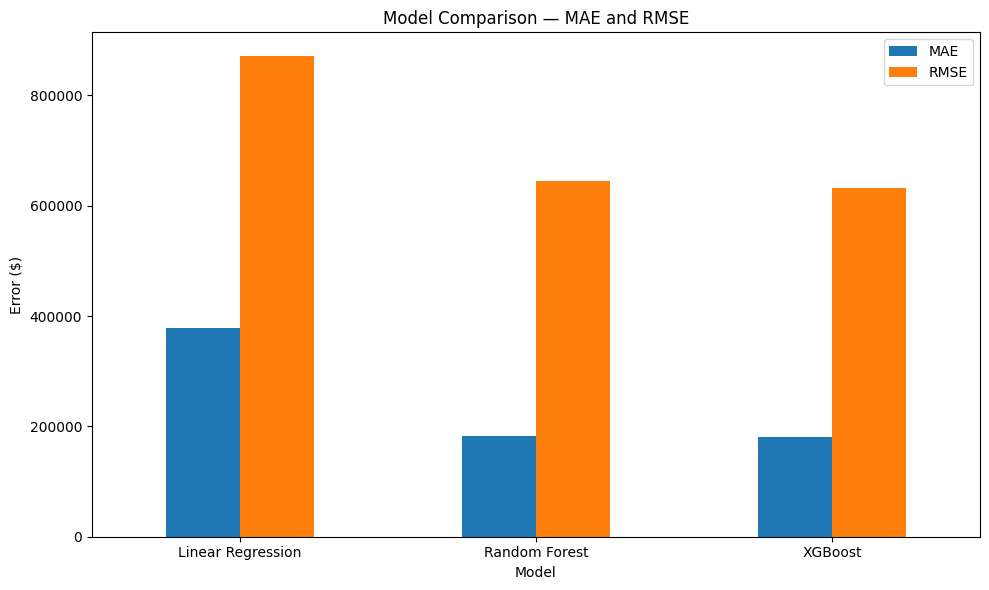

In [42]:
results_plot = results.set_index("Model")

results_plot[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Model Comparison — MAE and RMSE")
plt.xlabel("Model")
plt.ylabel("Error ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

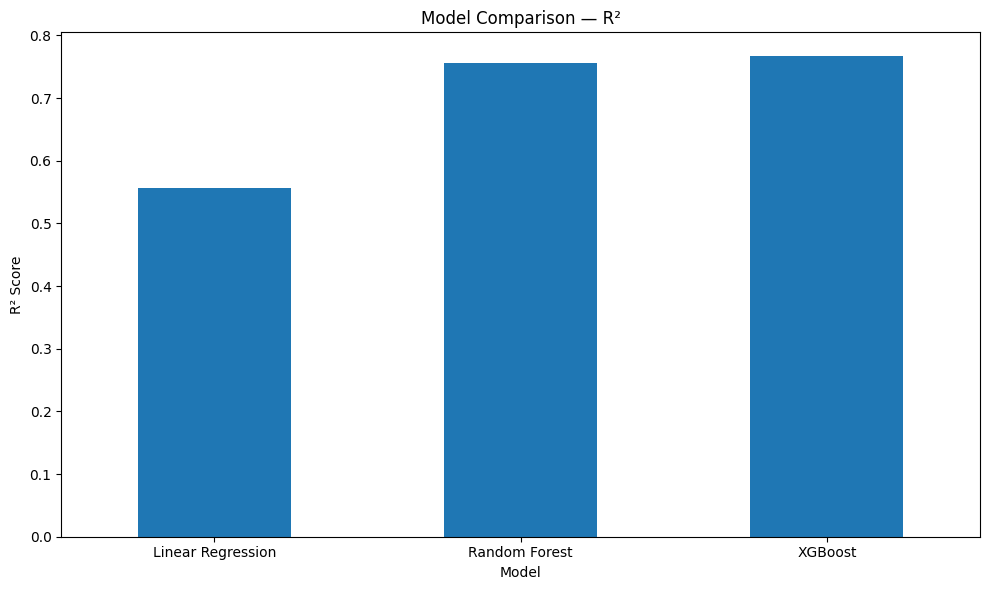

In [43]:
results_plot["R2"].plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Model Comparison — R²")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Actual vs. Predicted Prices

A useful regression diagnostic is to compare actual prices with predicted prices.

The dashed diagonal represents perfect predictions. Points farther from the line indicate larger prediction errors.

The chart uses the **best-performing model selected by RMSE**.

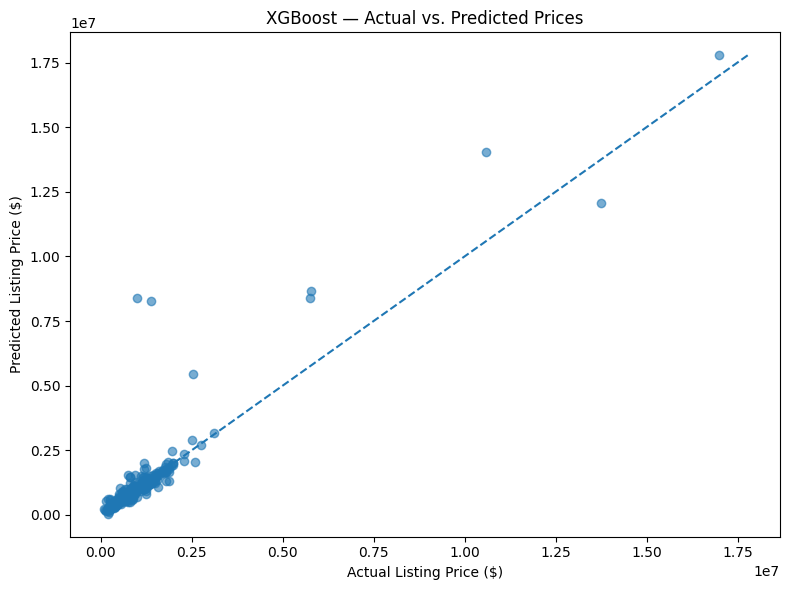

In [44]:
prediction_map = {
    "Linear Regression": linear_predictions,
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions,
}

best_model_row = results.sort_values(
    by="RMSE",
    ascending=True,
).iloc[0]

best_model_name = best_model_row["Model"]
best_predictions = prediction_map[best_model_name]

min_price = min(y_test.min(), best_predictions.min())
max_price = max(y_test.max(), best_predictions.max())

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6,
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--",
)

plt.xlabel("Actual Listing Price ($)")
plt.ylabel("Predicted Listing Price ($)")
plt.title(f"{best_model_name} — Actual vs. Predicted Prices")

plt.tight_layout()
plt.show()

# Prediction Error Analysis

The prediction error is defined as:

**Actual Price − Predicted Price**

- Positive error → the model underpredicted the price
- Negative error → the model overpredicted the price

Inspecting the largest absolute errors helps identify properties or market conditions that are difficult for the model to predict.

In [45]:
prediction_analysis = pd.DataFrame({
    "actual_price": y_test.to_numpy(),
    "predicted_price": best_predictions,
})

prediction_analysis["error"] = (
    prediction_analysis["actual_price"]
    - prediction_analysis["predicted_price"]
)

prediction_analysis["absolute_error"] = (
    prediction_analysis["error"].abs()
)

prediction_analysis.sort_values(
    by="absolute_error",
    ascending=False,
).head(10)

,actual_price,predicted_price,error,absolute_error
71,1000000.0,8.382549e+06,-7382549.000,7382549.000
215,1395000.0,8.258778e+06,-6863778.000,6863778.000
18,10599000.0,1.403380e+07,-3434799.000,3434799.000
266,2550000.0,5.449282e+06,-2899282.000,2899282.000
313,5775000.0,8.647924e+06,-2872924.000,2872924.000
271,5750000.0,8.375006e+06,-2625006.000,2625006.000
341,13750000.0,1.205968e+07,1690317.000,1690317.000
31,1200000.0,2.023758e+06,-823758.500,823758.500
376,749000.0,1.541435e+06,-792435.125,792435.125
347,17000000.0,1.778077e+07,-780768.000,780768.000


In [46]:
prediction_analysis.sort_values(
    by="absolute_error",
    ascending=False
).head(10)

,actual_price,predicted_price,error,absolute_error
71,1000000.0,8.382549e+06,-7382549.000,7382549.000
215,1395000.0,8.258778e+06,-6863778.000,6863778.000
18,10599000.0,1.403380e+07,-3434799.000,3434799.000
266,2550000.0,5.449282e+06,-2899282.000,2899282.000
313,5775000.0,8.647924e+06,-2872924.000,2872924.000
271,5750000.0,8.375006e+06,-2625006.000,2625006.000
341,13750000.0,1.205968e+07,1690317.000,1690317.000
31,1200000.0,2.023758e+06,-823758.500,823758.500
376,749000.0,1.541435e+06,-792435.125,792435.125
347,17000000.0,1.778077e+07,-780768.000,780768.000


# XGBoost Feature Importance

Feature importance shows which transformed features were most useful to the XGBoost model.

Because categorical variables are one-hot encoded, individual ZIP codes and home-type categories can appear as separate transformed features.

> **Interpretation note:** Feature importance describes model behavior; it does not establish that a feature causes changes in listing price.

In [47]:
# Extract the trained XGBoost estimator from the pipeline.
xgb_model = xgb_pipeline.named_steps["model"]

In [48]:
# Get feature names after imputation and one-hot encoding.
xgb_feature_names = (
    xgb_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [49]:
# Extract XGBoost feature importance values.
xgb_importance = xgb_model.feature_importances_

In [50]:
feature_importance = pd.DataFrame({
    "feature": xgb_feature_names,
    "importance": xgb_importance,
})

In [51]:
# Rank features from most to least important.
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False,
)

In [52]:
feature_importance.head(20)

,feature,importance
49,cat__zip_code_11236,0.132156
22,cat__zip_code_11201,0.111890
2,num__living_area,0.108060
8,num__zestimate,0.089591
28,cat__zip_code_11209,0.069603
4,num__longitude,0.059716
1,num__bathrooms,0.050457
6,num__rent_estimate,0.046286
36,cat__zip_code_11217,0.043592
53,cat__zip_code_11249,0.037203


## Plot Feature Importance

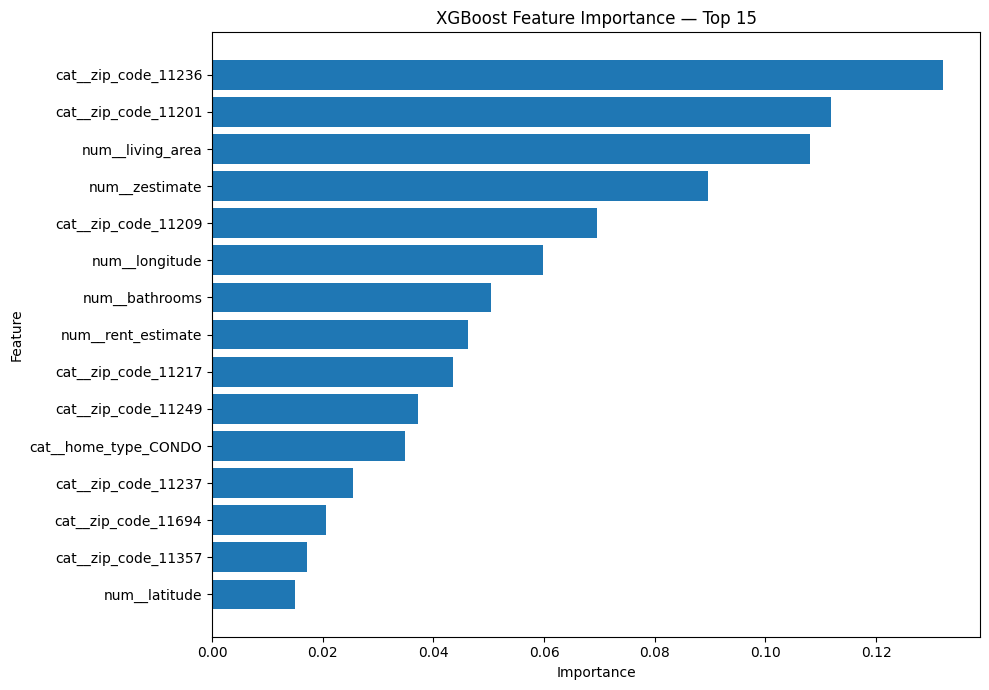

In [53]:
# Plot the 15 most important transformed features.
top_features = feature_importance.head(15).sort_values(
    by="importance",
    ascending=True,
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance — Top 15")

plt.tight_layout()
plt.show()

# Save the Best Model

The model selected using the evaluation results is saved as a complete pipeline.

The saved object contains:
1. missing-value imputation,
2. numerical scaling,
3. categorical encoding,
4. the trained estimator.

This makes the model easier to reuse in the Streamlit application without manually reproducing preprocessing steps.

In [54]:
# Select the model that achieved the lowest RMSE.
model_map = {
    "Linear Regression": linear_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgb_pipeline,
}

best_model = model_map[best_model_name]

In [55]:
# Save the complete preprocessing + model pipeline.
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "nyc_real_estate_price_model.pkl"

joblib.dump(best_model, MODEL_PATH)

print(f"Saved best model: {best_model_name}")
print(f"Model path: {MODEL_PATH}")

Saved best model: XGBoost
Model path: ../models/nyc_real_estate_price_model.pkl


In [56]:
# Reload the saved pipeline.
loaded_model = joblib.load(MODEL_PATH)

# Generate predictions using the reloaded model.
loaded_predictions = loaded_model.predict(X_test)

max_prediction_difference = np.max(
    np.abs(best_predictions - loaded_predictions)
)

print(
    "Maximum prediction difference after reload: "
    f"{max_prediction_difference:.10f}"
)

if not np.allclose(best_predictions, loaded_predictions):
    raise AssertionError(
        "Reloaded model predictions do not match the original predictions."
    )

print("Model reload verification passed.")

Maximum prediction difference after reload: 0.0000000000
Model reload verification passed.


In [57]:
# Confirm predictions from the reloaded model.
loaded_predictions[:10]

array([ 967999.1 ,  210517.1 , 1068365.8 ,  761969.  , 1427843.1 ,
        597599.56,  529539.06, 1633786.1 ,  993727.  , 1495067.5 ],
      dtype=float32)

In [58]:
loaded_predictions[:10]

array([ 967999.1 ,  210517.1 , 1068365.8 ,  761969.  , 1427843.1 ,
        597599.56,  529539.06, 1633786.1 ,  993727.  , 1495067.5 ],
      dtype=float32)

In [59]:
# Final model metrics.
print(f"Best model: {best_model_name}")
print(f"MAE:  ${best_model_row['MAE']:,.2f}")
print(f"RMSE: ${best_model_row['RMSE']:,.2f}")
print(f"R²:   {best_model_row['R2']:.4f}")

Best model: XGBoost
MAE:  $181,014.34
RMSE: $631,162.02
R²:   0.7665


# Conclusion

This phase developed an end-to-end machine-learning workflow for NYC real-estate listing price prediction.

### Completed

- Validated the `listing_price` target
- Selected property, location, listing, and market-value features
- Preserved missingness indicators from feature engineering
- Excluded identifiers and target-derived features to prevent leakage
- Treated ZIP codes as categorical variables
- Built reusable preprocessing pipelines
- Trained Linear Regression, Random Forest, and XGBoost
- Evaluated models using MAE, RMSE, and R²
- Selected the best model using test-set RMSE
- Analyzed prediction errors
- Examined XGBoost feature importance
- Saved and verified the complete best-model pipeline

### Model Selection

The final model was selected based on the **lowest RMSE** on the held-out test set. This provides an objective comparison rather than assuming that XGBoost must be the winner.

### Next Steps

Potential improvements include:
- cross-validation,
- hyperparameter tuning,
- geographic/group-aware validation,
- log-transforming the highly skewed price target,
- additional neighborhood-level features,
- integration of external NYC property and market datasets,
- model monitoring after deployment.

The saved model can now be integrated into the project's Streamlit application for real-time NYC property price prediction.